# 01 - Exploratory Data Analysis
## Airbnb Price Prediction - Austin, TX

**Purpose of this notebook**  
Understand the data before touching it. Every cleaning decision in `02_Cleaning.ipynb` 
and every feature created in `03_Features.ipynb` will be grounded in observations made here.

**What this notebook does NOT do**  
- No data modification (no imputation, no filtering, no encoding)  
- No model training  
- No use of the test set (not yet created)

**Snapshot**  
> Inside Airbnb - Austin, TX. Date: 16 September, 2025 
> Source: http://insideairbnb.com/get-the-data

**Outline**
1. Setup & Data Loading
2. First Look - Shape, Types, Missing Values
3. Target Variable - `price`
4. Univariate Analysis
5. Bivariate Analysis - Features vs. Price
6. Geographic Analysis
7. Conclusion & Handoff to 02_Cleaning

---
## 1. Setup & Data Loading

We load the two raw files from Inside Airbnb. `listings.csv` is the primary file 
for this project. `calendar.csv` is loaded for reference but will only be used 
in a future notebook for seasonality features.

**Snapshot**: Inside Airbnb — Austin, TX — September 17, 2025  
**Source**: http://insideairbnb.com/get-the-data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)

print('Libraries loaded')

Libraries loaded


In [3]:
LISTINGS_PATH = '../data/raw/Austin/listings.csv.gz'

listings_df = pd.read_csv(LISTINGS_PATH, low_memory=False)

print(f'Loaded listings.csv {listings_df.shape[0]:,} rows × {listings_df.shape[1]} columns')

Loaded listings.csv 10,533 rows × 79 columns


In [4]:
print(listings_df.dtypes.value_counts())
listings_df.head(3)

str        33
float64    25
int64      21
Name: count, dtype: int64


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,...,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,5456,https://www.airbnb.com/rooms/5456,20250916040734,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,https://www.airbnb.com/users/show/8028,Sylvia,2009-02-16,"Austin, TX",I am a licensed Real Estate Broker and owner o...,within a few hours,100%,90%,t,https://a0.muscache.com/im/users/8028/profile_...,https://a0.muscache.com/im/users/8028/profile_...,East Downtown,1.00,2.00,"['email', 'phone']",t,t,Neighborhood highlights,78702,NaN,...,NaN,t,13,35,65,328,2025-09-17,708,25,1,81,33,150,14550.00,2009-03-19,2025-09-02,4.85,4.88,4.86,4.90,4.82,4.73,4.79,NaN,f,1,1,0,0,3.52
1,6448,https://www.airbnb.com/rooms/6448,20250916040734,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,https://www.airbnb.com/users/show/14156,Amy,2009-04-20,"Austin, TX","We are a family of four (with teenagers, all o...",within an hour,100%,96%,t,https://a0.muscache.com/im/users/14156/profile...,https://a0.muscache.com/im/users/14156/profile...,Zilker,1.00,2.00,"['email', 'phone']",t,t,Neighborhood highlights,78704,NaN,...,NaN,t,12,30,50,316,2025-09-17,339,14,1,61,20,84,13440.00,2011-09-06,2025-08-20,4.97,4.97,4.96,4.99,4.98,4.97,4.88,NaN,t,1,1,0,0,1.98
2,8502,https://www.airbnb.com/rooms/8502,20250916040734,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,25298,https://www.airbnb.com/users/show/25298,Karen,2009-07-11,"Austin, TX",I handle the reservations at the studio on the...,within a day,100%,60%,f,https://a0.muscache.com/im/users/25298/profile...,https://a0.muscache.com/im/users/25298/profile...,East Riverside,1.00,1.00,"['email', 'phone']",t,f,NaN,78741,NaN,...,NaN,t,29,59,88,88,2025-09-17,54,1,0,88,2,8,304.00,2010-02-19,2025-05-05,4.57,4.55,4.67,4.85,4.88,4.69,4.63,NaN,f,1,1,0,0,0.28


In [5]:
missing = (
    listings_df.isnull().sum()
    .rename('n_missing')
    .to_frame()
    .assign(pct_missing=lambda x: 100 * x['n_missing'] / len(listings_df))
    .query('n_missing > 0')
    .sort_values('pct_missing', ascending=False)
)

print(f'{len(missing)} columns with missing values out of {listings_df.shape[1]}')
missing

43 columns with missing values out of 79


,n_missing,pct_missing
license,10533,100.00
calendar_updated,10533,100.00
neighbourhood_group_cleansed,10533,100.00
neighbourhood,5173,49.11
neighborhood_overview,5173,49.11
host_about,3575,33.94
host_location,1875,17.80
review_scores_cleanliness,1624,15.42
review_scores_checkin,1624,15.42
review_scores_value,1624,15.42


---
## 2. First Look: Shape, Types and Missing Values

Goal: build a rapid inventory of the dataset. No modification, only diagnosis.

In [6]:
CANDIDATE_FEATURES = [
    'price',
    'room_type', 'property_type', 'accommodates', 'bedrooms', 'beds',
    'bathrooms_text',
    'latitude', 'longitude', 'neighbourhood_cleansed',
    'host_since', 'host_is_superhost', 'host_listings_count',
    'host_identity_verified',
    'review_scores_rating', 'number_of_reviews', 'reviews_per_month',
    'minimum_nights', 'availability_365',
    'instant_bookable',
]

present = [c for c in CANDIDATE_FEATURES if c in listings_df.columns]
absent  = [c for c in CANDIDATE_FEATURES if c not in listings_df.columns]

print(f'Absent: {absent}')
listings_df[present].isnull().mean().sort_values(ascending=False).to_frame('pct_missing').round(3)

Absent: []


,pct_missing
review_scores_rating,0.15
reviews_per_month,0.15
host_is_superhost,0.04
bathrooms_text,0.00
price,0.00
bedrooms,0.00
host_since,0.00
host_identity_verified,0.00
host_listings_count,0.00
beds,0.00


---
## 3. Target Variable: `price`

The `price` column is stored as a string (`"$150.00"`). We convert it to float 
and study its distribution to justify the modeling choice of using `log(price)` 
as the model target.

In [7]:
listings_df['price_num'] = (
    listings_df['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .replace('nan', np.nan)
    .astype(float)
)

listings_df['price_num'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

count   10517.00
mean      414.54
std      2896.81
min         8.00
1%         28.00
5%         44.00
25%        86.00
50%       135.00
75%       226.00
95%       700.40
99%      2431.92
max     50000.00
Name: price_num, dtype: float64

In [8]:
n_null  = listings_df['price_num'].isnull().sum()
n_zero  = (listings_df['price_num'] == 0).sum()
n_below = (listings_df['price_num'] < 10).sum()
n_above = (listings_df['price_num'] > 2500).sum()

print(f'Missing : {n_null} ({100*n_null/len(listings_df):.1f}%)')
print(f'Zero    : {n_zero}')
print(f'Below $10 : {n_below}')
print(f'Above $2500 : {n_above}')

Missing : 16 (0.2%)
Zero    : 0
Below $10 : 1
Above $2500 : 101


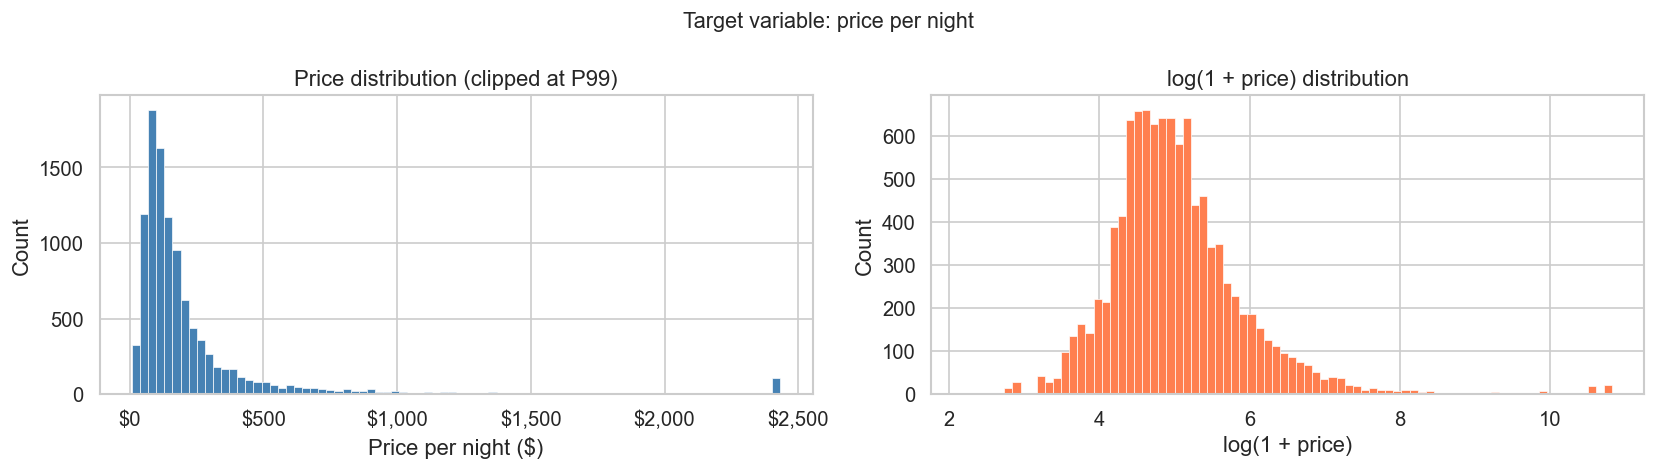

Skewness raw : 15.31
Skewness log : 1.61


In [9]:
p99 = listings_df['price_num'].quantile(0.99)
price_clean = listings_df['price_num'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(price_clean.clip(upper=p99), bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Price distribution (clipped at P99)')
axes[0].set_xlabel('Price per night ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

axes[1].hist(np.log1p(price_clean), bins=80, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_title('log(1 + price) distribution')
axes[1].set_xlabel('log(1 + price)')
axes[1].set_ylabel('Count')

plt.suptitle('Target variable: price per night', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Skewness raw : {price_clean.skew():.2f}')
print(f'Skewness log : {np.log1p(price_clean).skew():.2f}')

**Key takeaways**

The raw price distribution has a skewness of 15.31, heavily driven by a small number 
of extreme listings (max $50,000). After log transformation, skewness drops to 1.61 
and the distribution is approximately bell-shaped. We will therefore use `log1p(price)` 
as the model target throughout the project.

Flagged for `02_Cleaning`:
- 16 missing prices and 1 listing below $10 → drop
- 101 listings above $2,500 (P99) → drop with explicit documentation

## 4. Univariate Analysis

We examine the distribution of each candidate feature independently. 
The goal is to identify encoding requirements, missing value patterns, and cardinality 
before any feature interacts with the target.

In [10]:
print(listings_df['room_type'].value_counts())
print(f'\nUnique values: {listings_df["room_type"].nunique()}')

room_type
Entire home/apt    9078
Private room       1316
Hotel room           74
Shared room          65
Name: count, dtype: int64

Unique values: 4


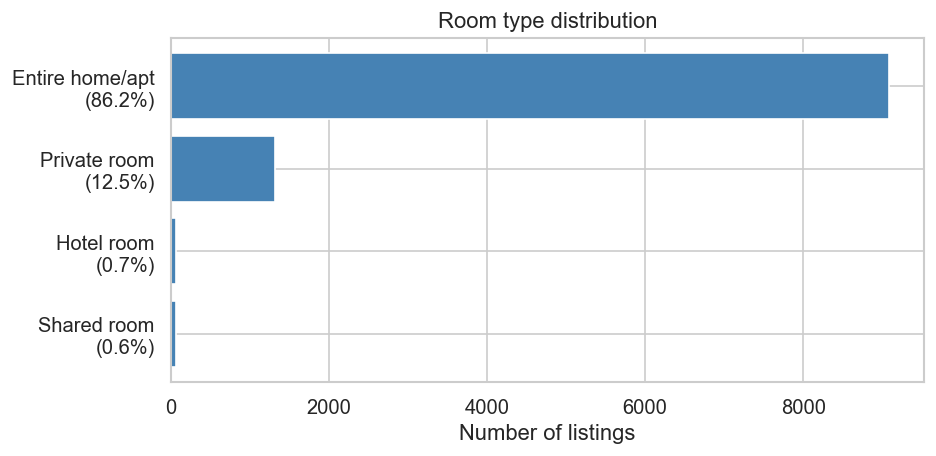

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

room_counts = listings_df['room_type'].value_counts()
pcts = 100 * room_counts / room_counts.sum()
labels = [f'{t}\n({p:.1f}%)' for t, p in zip(room_counts.index, pcts)]

ax.barh(labels, room_counts.values, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Room type distribution')
ax.set_xlabel('Number of listings')

plt.tight_layout()
plt.show()

In [12]:
print(f'Unique property types: {listings_df["property_type"].nunique()}')
listings_df['property_type'].value_counts().head(15)

Unique property types: 61


property_type
Entire home                    4490
Entire rental unit             1970
Entire condo                    898
Private room in home            872
Entire guesthouse               586
Room in hotel                   245
Entire townhouse                233
Entire guest suite              200
Private room in rental unit     146
Entire bungalow                 143
Tiny home                       136
Camper/RV                        70
Entire loft                      48
Entire cottage                   45
Entire serviced apartment        45
Name: count, dtype: int64

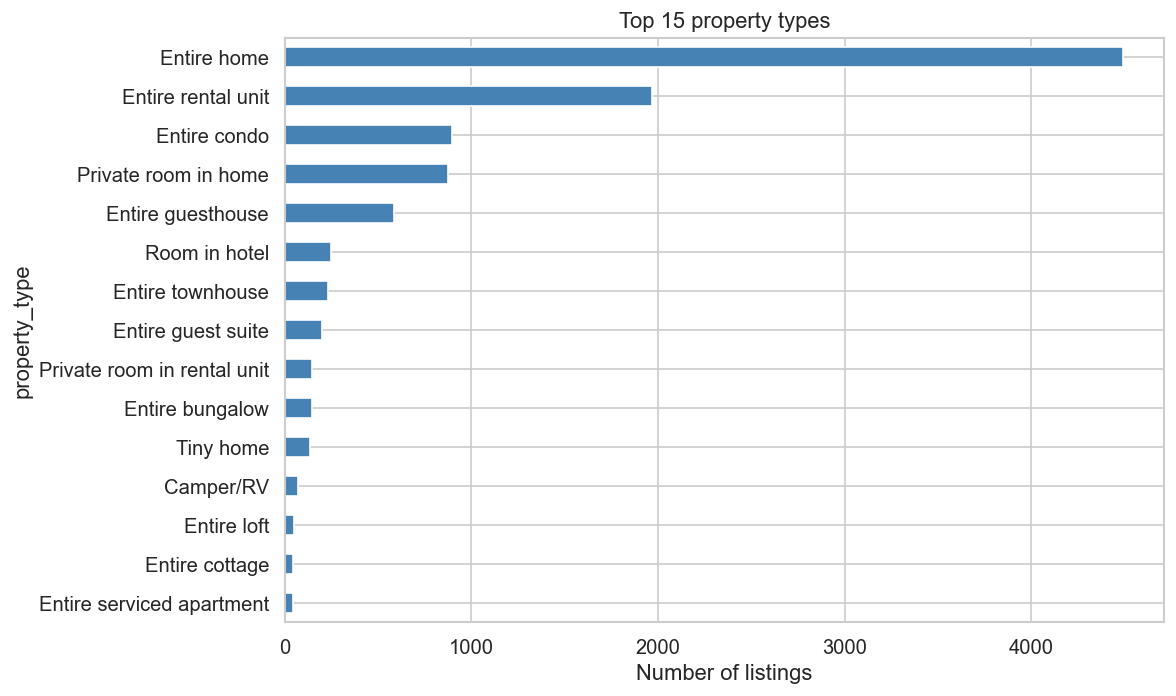

Top 15 cover 96.1% of all listings


In [13]:
top15 = listings_df['property_type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 property types')
ax.set_xlabel('Number of listings')

plt.tight_layout()
plt.show()

coverage = 100 * top15.sum() / len(listings_df)
print(f'Top 15 cover {coverage:.1f}% of all listings')

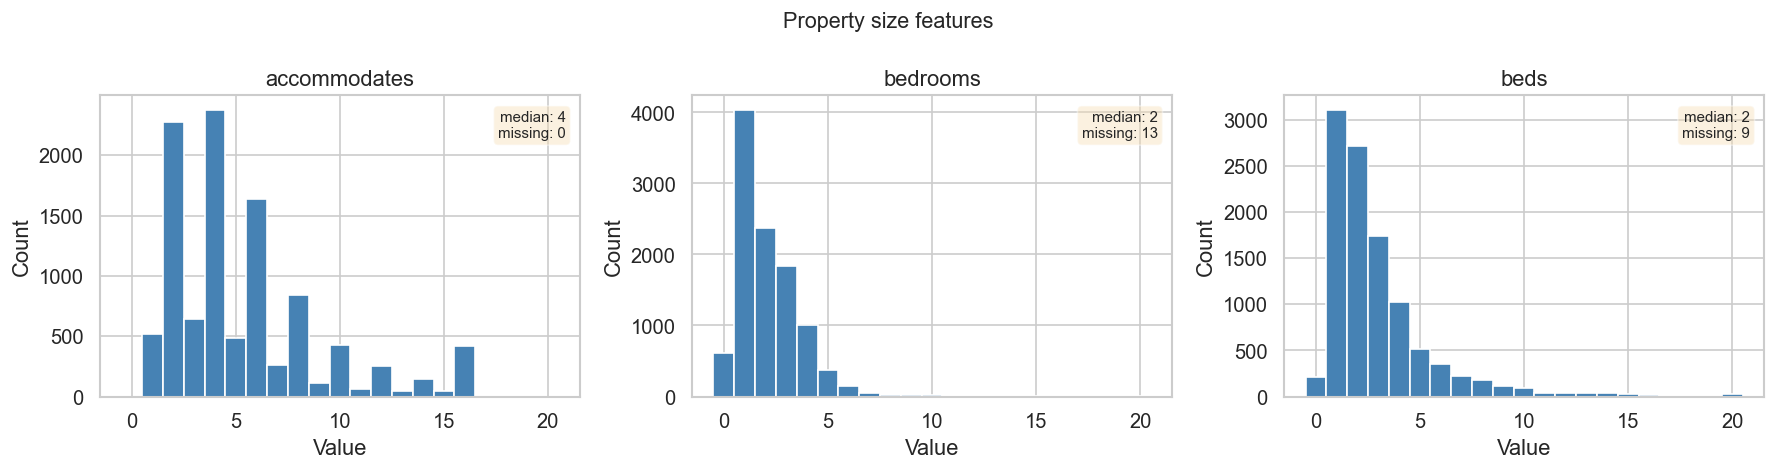

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['accommodates', 'bedrooms', 'beds']):
    vals = listings_df[col].dropna()
    ax.hist(vals.clip(upper=20), bins=range(0, 22), color='steelblue', 
            edgecolor='white', align='left')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.text(0.97, 0.95, f'median: {vals.median():.0f}\nmissing: {listings_df[col].isnull().sum()}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.suptitle('Property size features', fontsize=13)
plt.tight_layout()
plt.show()

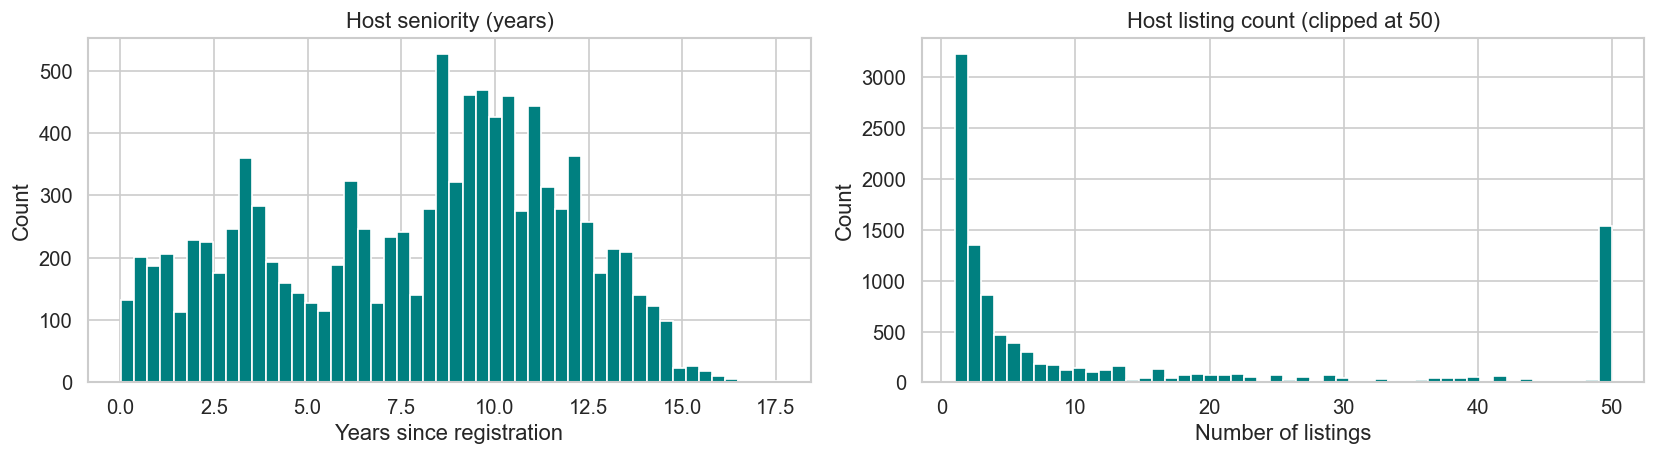

Median seniority : 8.7 years
Hosts with >1 listing : 69.3%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

SNAPSHOT_DATE = pd.Timestamp('2025-09-17')
host_since = pd.to_datetime(listings_df['host_since'], errors='coerce')
seniority_years = (SNAPSHOT_DATE - host_since).dt.days / 365

axes[0].hist(seniority_years.dropna(), bins=50, color='teal', edgecolor='white')
axes[0].set_title('Host seniority (years)')
axes[0].set_xlabel('Years since registration')
axes[0].set_ylabel('Count')

axes[1].hist(listings_df['host_listings_count'].clip(upper=50).dropna(), 
             bins=50, color='teal', edgecolor='white')
axes[1].set_title('Host listing count (clipped at 50)')
axes[1].set_xlabel('Number of listings')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Median seniority : {seniority_years.median():.1f} years')
print(f'Hosts with >1 listing : {100*(listings_df["host_listings_count"] > 1).mean():.1f}%')

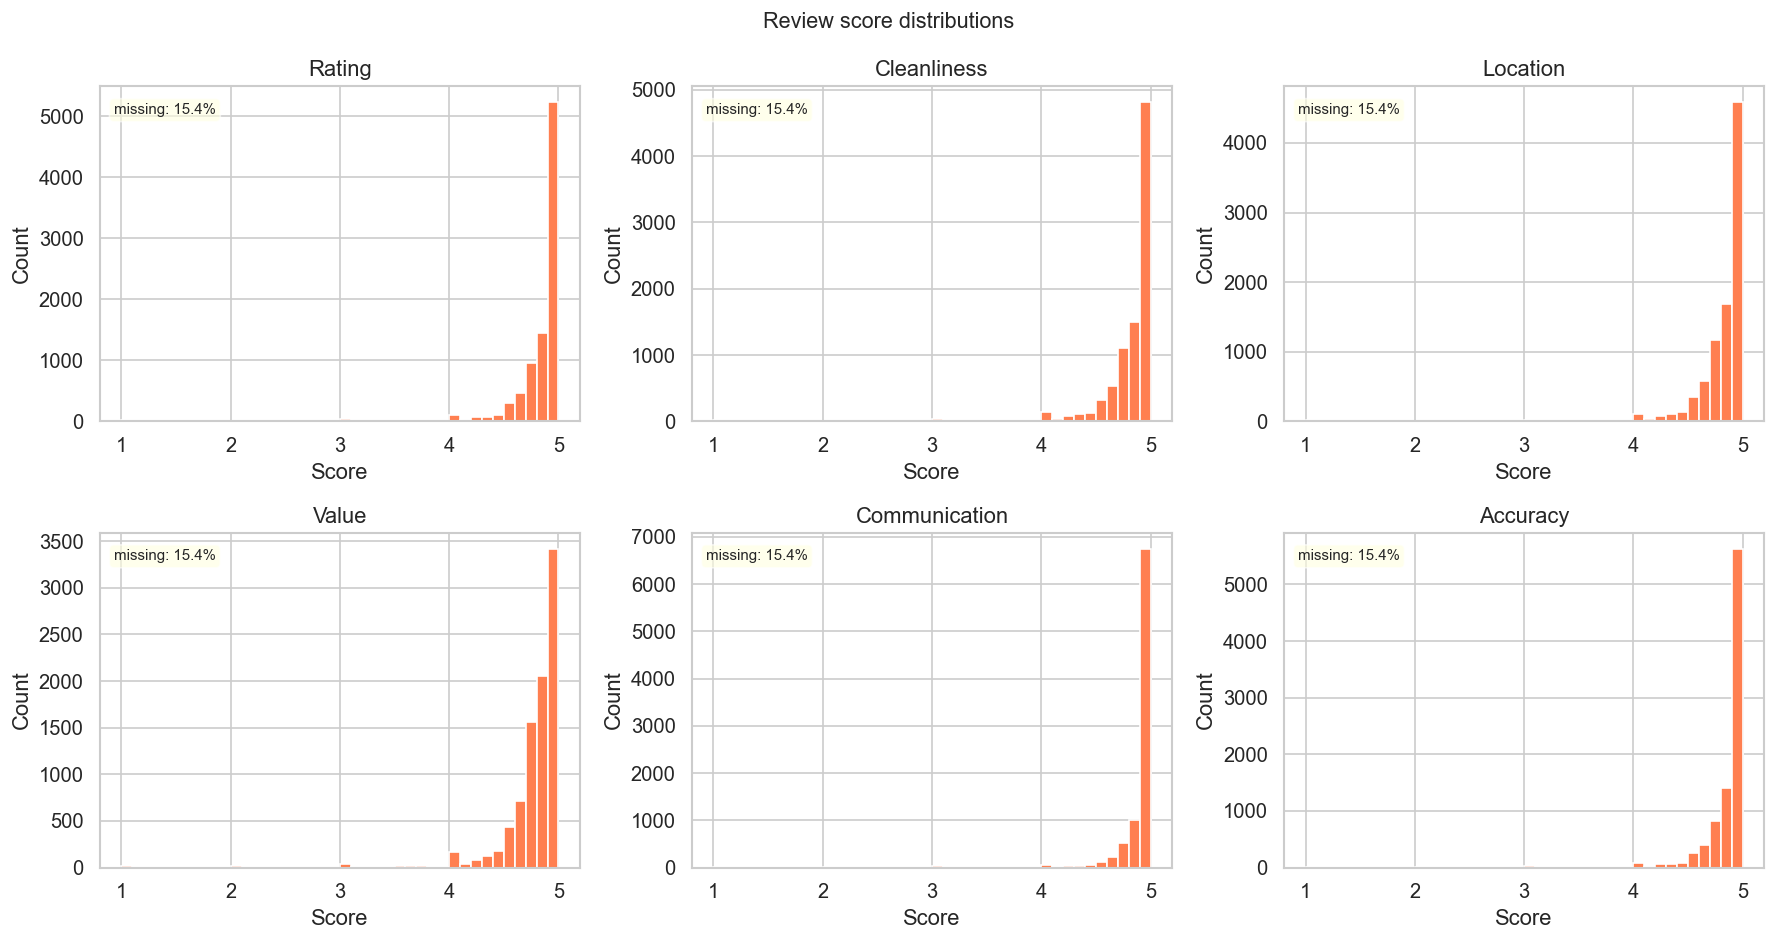

In [16]:
review_cols = [
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'review_scores_communication', 'review_scores_accuracy',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(review_cols):
    vals = listings_df[col].dropna()
    axes[i].hist(vals, bins=40, color='coral', edgecolor='white')
    axes[i].set_title(col.replace('review_scores_', '').capitalize())
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
    miss_pct = 100 * listings_df[col].isnull().mean()
    axes[i].text(0.03, 0.95, f'missing: {miss_pct:.1f}%',
                 transform=axes[i].transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.6))

plt.suptitle('Review score distributions', fontsize=13)
plt.tight_layout()
plt.show()

Unique neighbourhoods: 43


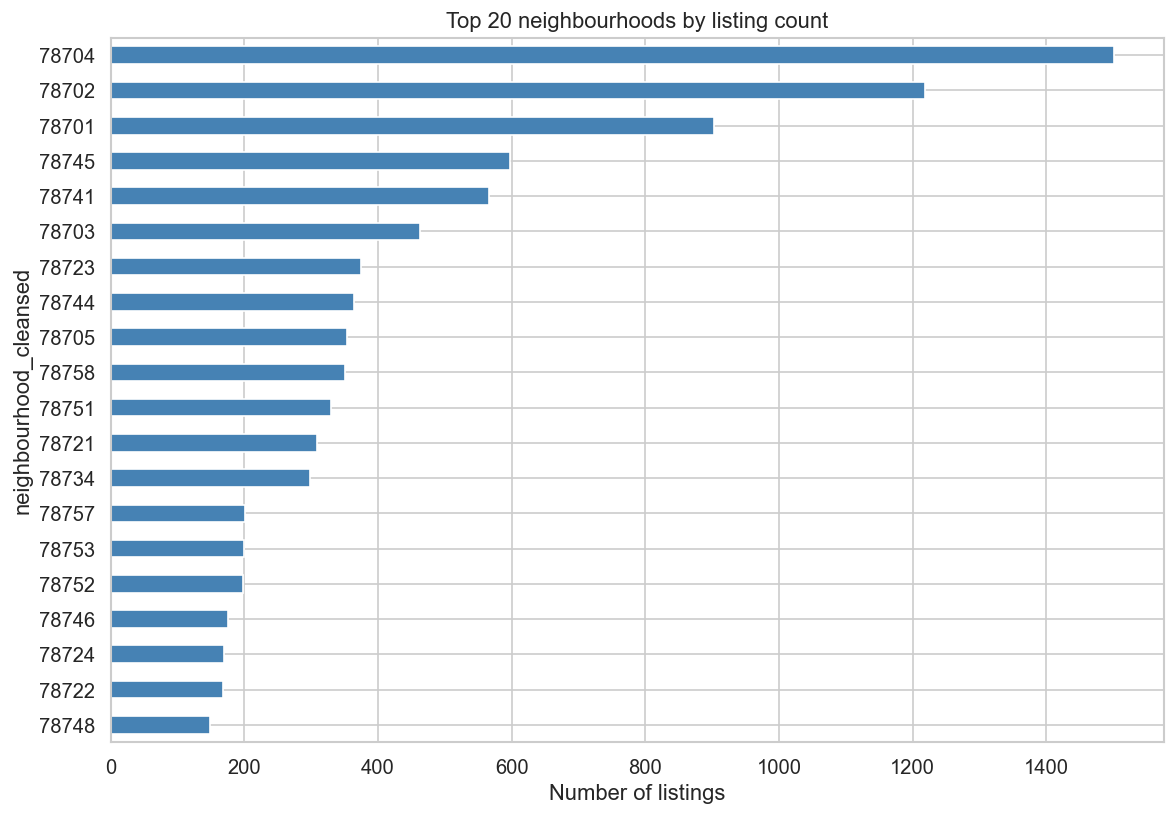

In [17]:
print(f'Unique neighbourhoods: {listings_df["neighbourhood_cleansed"].nunique()}')

top20 = listings_df['neighbourhood_cleansed'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 neighbourhoods by listing count')
ax.set_xlabel('Number of listings')

plt.tight_layout()
plt.show()

In [18]:
print(f'Unique ZIP codes: {listings_df["neighbourhood_cleansed"].nunique()}')

Unique ZIP codes: 43


In [19]:
print(listings_df['amenities'].iloc[0])
print(f'\nType: {type(listings_df["amenities"].iloc[0])}')

["Iron", "Private entrance", "Hot water", "Dishes and silverware", "Refrigerator", "HDTV with Amazon Prime Video, HBO Max, Hulu, Netflix, Roku", "Self check-in", "Keypad", "Wifi", "Heating", "Hair dryer", "Bed linens", "Long term stays allowed", "Patio or balcony", "Smoke alarm", "Essentials", "Luggage dropoff allowed", "Air conditioning", "Exterior security cameras on property", "Shampoo", "Extra pillows and blankets", "Coffee maker", "Microwave", "Kitchen", "Backyard", "Hangers"]

Type: <class 'str'>


In [20]:
import ast

amenity_counts = listings_df['amenities'].apply(
    lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0
)

print(f'Mean amenities per listing : {amenity_counts.mean():.1f}')
print(f'Min: {amenity_counts.min()} / Max: {amenity_counts.max()}')

Mean amenities per listing : 44.0
Min: 0 / Max: 109


**Key takeaways from univariate analysis**

- `room_type` has low cardinality (4 values), dominated by Entire home/apt at 86%. 
  One-hot encoding is appropriate.
- `property_type` has 61 unique values but the top 15 cover 96% of listings. 
  Rare types will be grouped into an "Other" category in `03_Features`.
- `bedrooms` and `beds` have negligible missing values (13 and 9 respectively), 
  easily imputable.
- All review scores share the exact same 15.4% missing rate, confirming these are 
  the same 1,624 listings with no reviews. A `has_reviews` binary flag must be 
  created before any imputation.
- `neighbourhood_cleansed` contains ZIP codes (43 unique values). 
  Target encoding is the right approach in `04_Preprocessing`.
- `amenities` is a JSON string averaging 44 items per listing. 
  It will be parsed and converted into a score in `03_Features`.

## 5. Bivariate Analysis: Features vs. Price

We examine how each key feature relates to price. This is where we form the 
hypotheses that will guide feature engineering in `03_Features`.

We work on a visualization subset clipped between P1 and P99 to avoid extreme 
outliers dominating the plots. This does NOT affect the actual data.

In [21]:
p01 = listings_df['price_num'].quantile(0.01)
p99 = listings_df['price_num'].quantile(0.99)
df_viz = listings_df[
    (listings_df['price_num'] >= p01) & 
    (listings_df['price_num'] <= p99)
].copy()

print(f'Viz subset: {len(df_viz):,} rows ({100*len(df_viz)/len(listings_df):.1f}% of total)')

Viz subset: 10,306 rows (97.8% of total)


C:\Users\capri_stunt\AppData\Local\Temp\ipykernel_10300\3905430437.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='room_type', y='price_num',


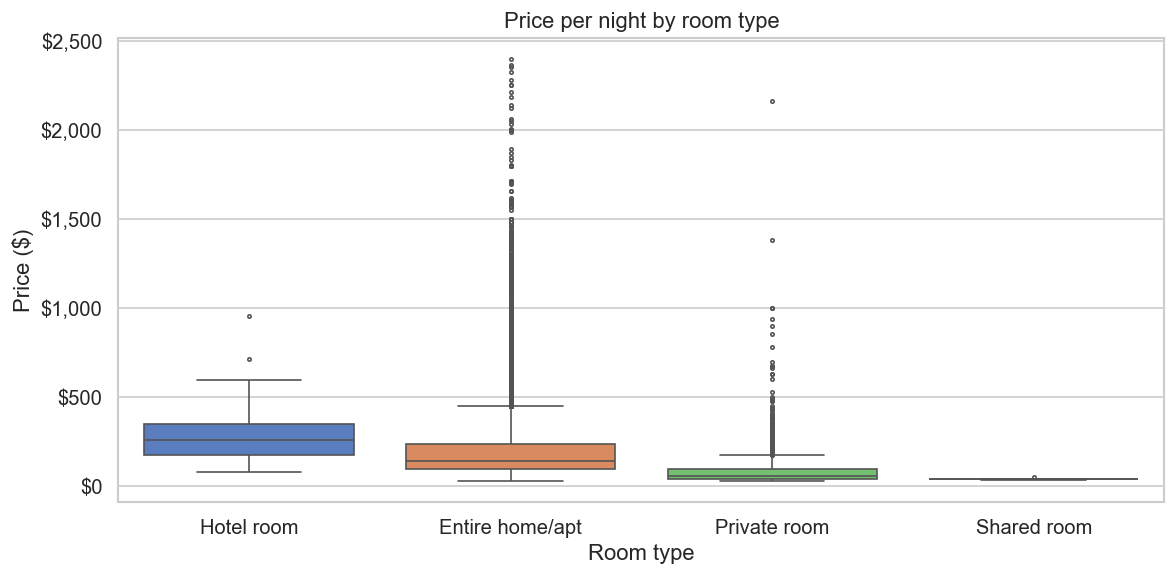

room_type
Hotel room        262.00
Entire home/apt   144.00
Private room       58.00
Shared room        40.00
Name: price_num, dtype: float64


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

order = df_viz.groupby('room_type')['price_num'].median().sort_values(ascending=False).index

sns.boxplot(data=df_viz, x='room_type', y='price_num',
            order=order, palette='muted', fliersize=2, ax=ax)

ax.set_title('Price per night by room type')
ax.set_xlabel('Room type')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

print(df_viz.groupby('room_type')['price_num'].median().sort_values(ascending=False))

C:\Users\capri_stunt\AppData\Local\Temp\ipykernel_10300\3986860022.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=acc_clipped, x='accommodates', y='price_num',


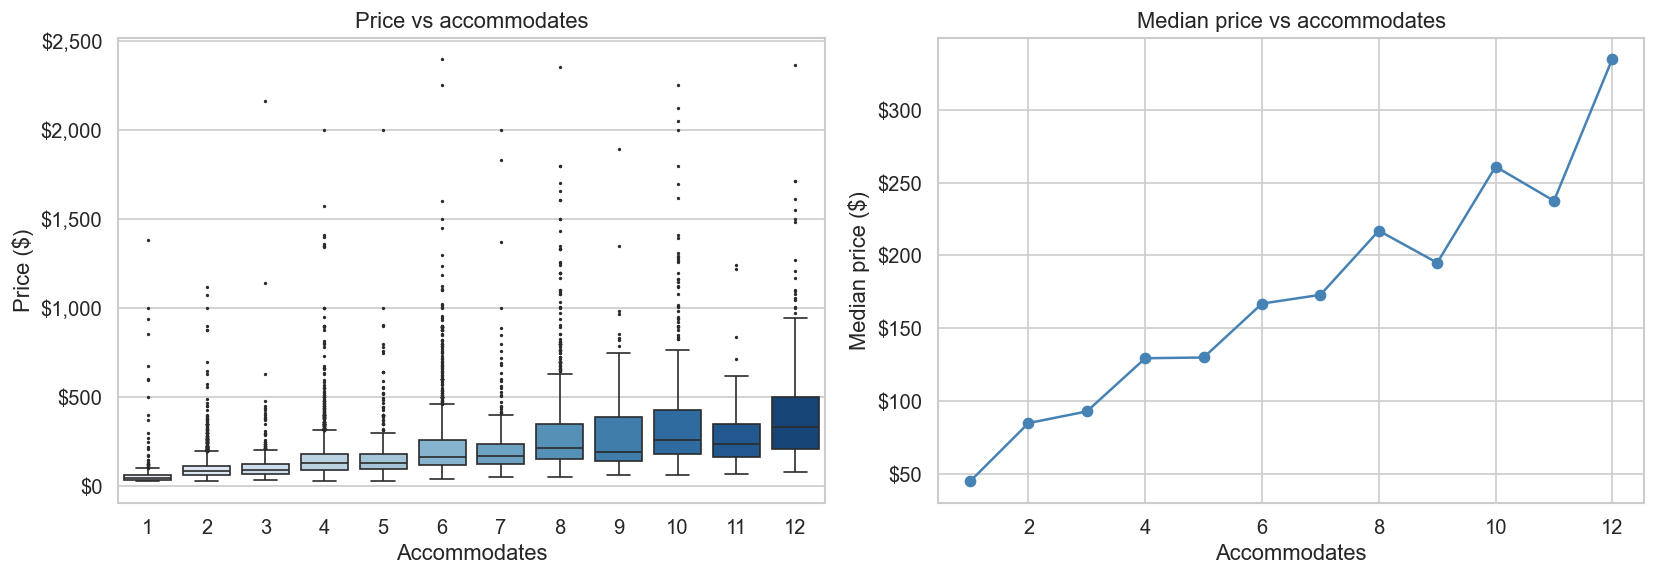

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_clipped = df_viz[df_viz['accommodates'] <= 12]

sns.boxplot(data=acc_clipped, x='accommodates', y='price_num',
            palette='Blues', fliersize=1, ax=axes[0])
axes[0].set_title('Price vs accommodates')
axes[0].set_xlabel('Accommodates')
axes[0].set_ylabel('Price ($)')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

median_by_acc = acc_clipped.groupby('accommodates')['price_num'].median()
axes[1].plot(median_by_acc.index, median_by_acc.values, 'o-', color='steelblue')
axes[1].set_title('Median price vs accommodates')
axes[1].set_xlabel('Accommodates')
axes[1].set_ylabel('Median price ($)')
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

C:\Users\capri_stunt\AppData\Local\Temp\ipykernel_10300\210627537.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top20, x='neighbourhood_cleansed', y='price_num',


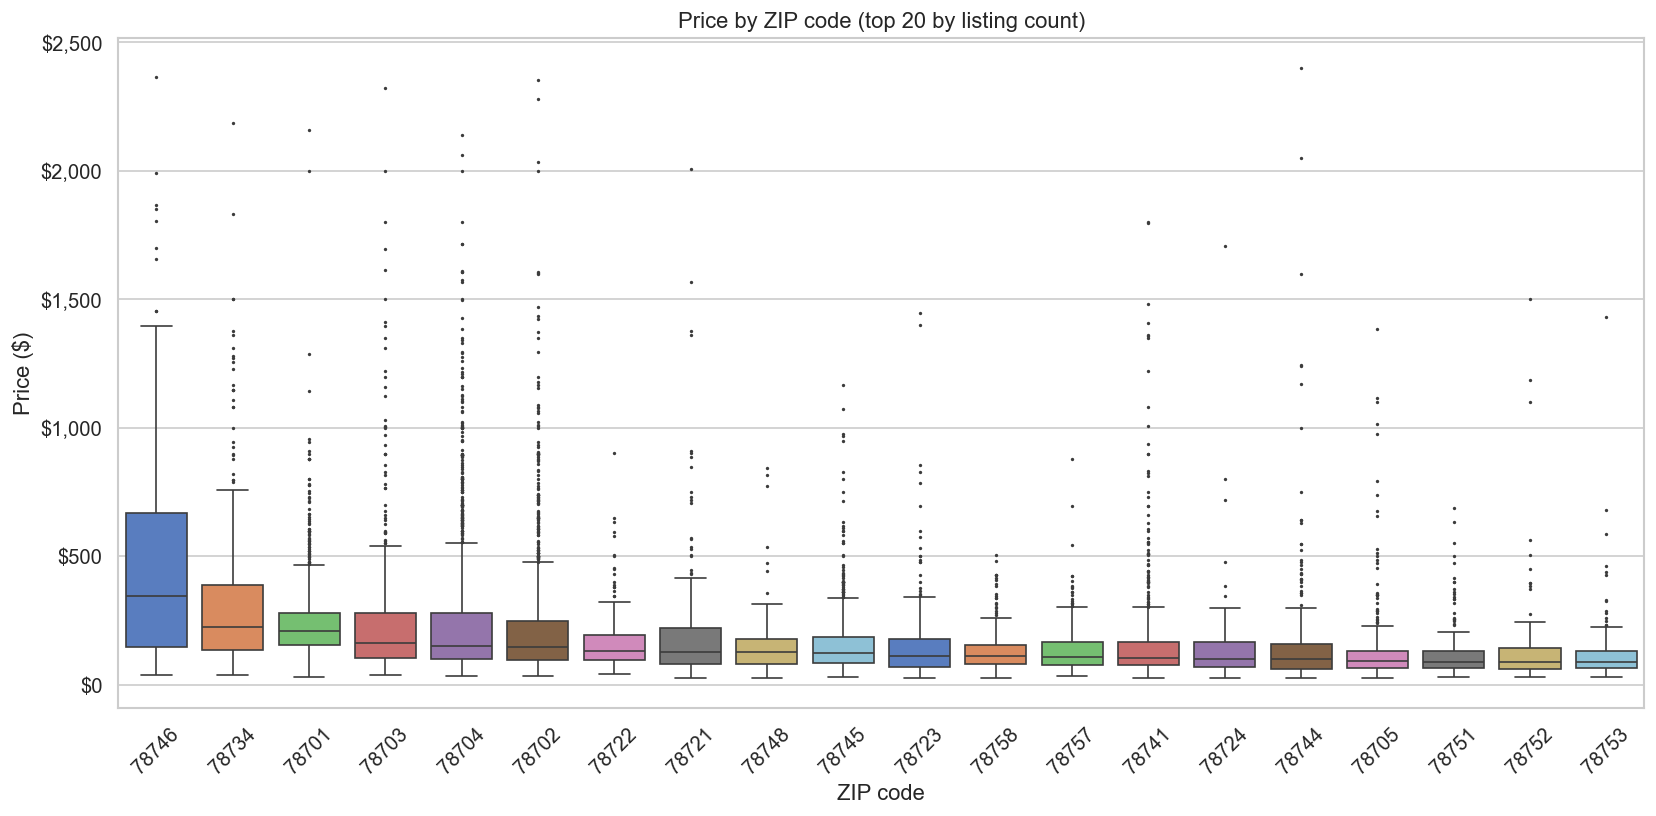

In [24]:
top20_nh = df_viz['neighbourhood_cleansed'].value_counts().head(20).index
df_top20 = df_viz[df_viz['neighbourhood_cleansed'].isin(top20_nh)]

order = df_top20.groupby('neighbourhood_cleansed')['price_num'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df_top20, x='neighbourhood_cleansed', y='price_num',
            order=order, palette='muted', fliersize=1, ax=ax)

ax.set_title('Price by ZIP code (top 20 by listing count)')
ax.set_xlabel('ZIP code')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

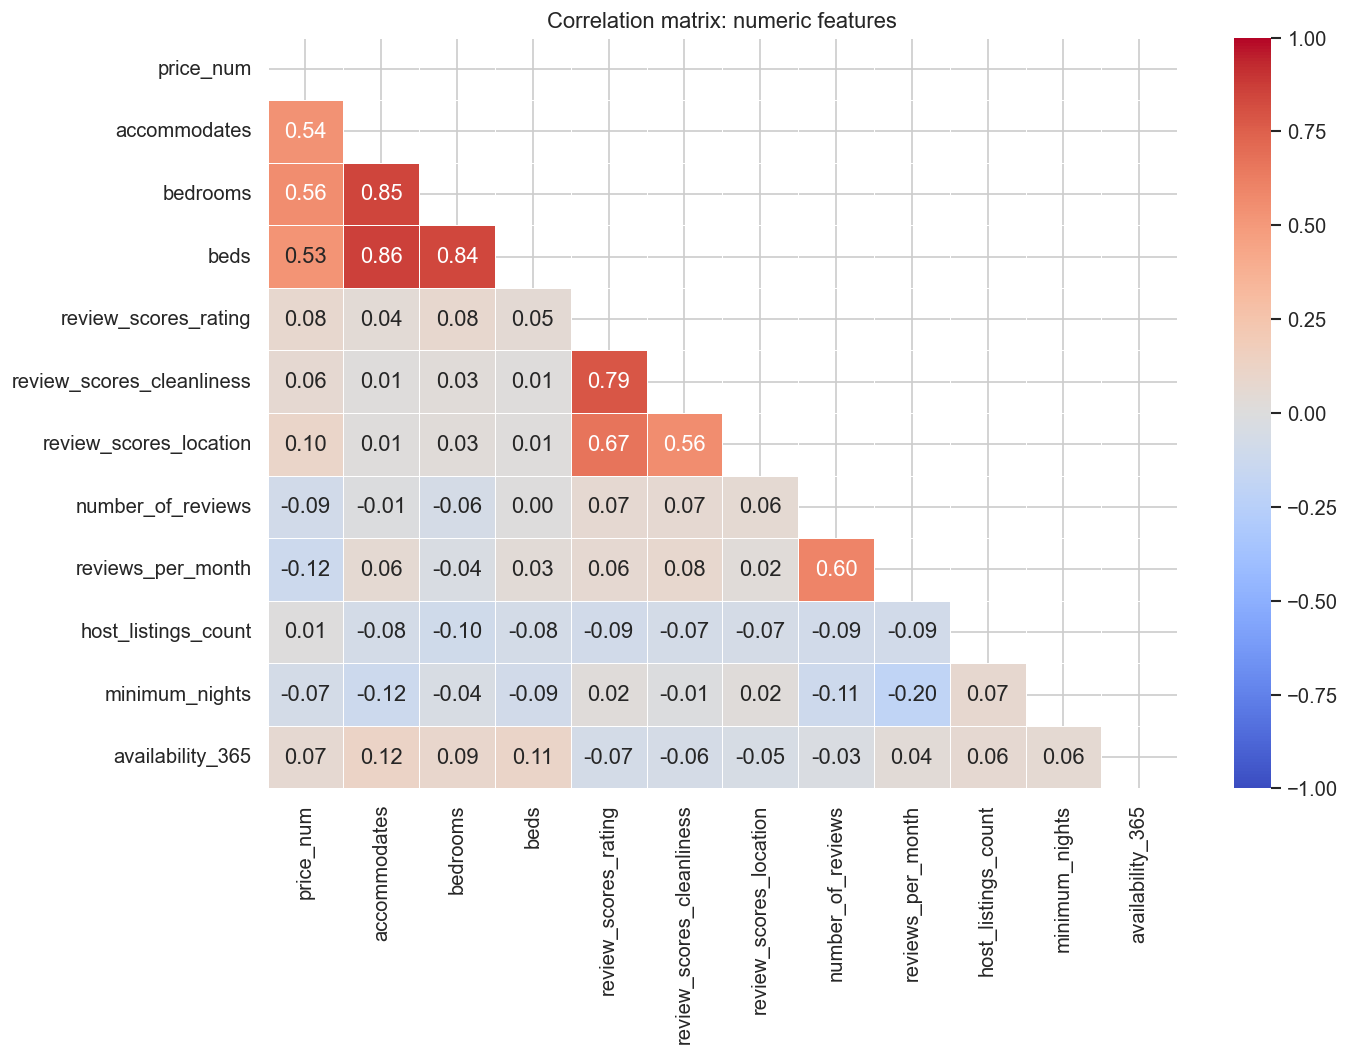

In [25]:
num_cols = [
    'price_num', 'accommodates', 'bedrooms', 'beds',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'number_of_reviews',
    'reviews_per_month', 'host_listings_count',
    'minimum_nights', 'availability_365'
]

corr = df_viz[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation matrix: numeric features')
plt.tight_layout()
plt.show()

**Key takeaways from bivariate analysis**

- Property size features (`bedrooms`, `accommodates`, `beds`) are the strongest 
  numeric predictors of price (r ≈ 0.54 to 0.56), but are highly collinear with 
  each other (r ≈ 0.85). Ridge regularization will be critical for linear models.
- ZIP code drives large price differences: median ranges from ~$100 to ~$350 
  across the top 20 ZIP codes, confirming location as a primary price driver.
- Review scores are weakly correlated with price but strongly correlated with 
  each other. We will keep only `review_scores_rating` as a representative.
- `room_type` shows a clear price hierarchy: Hotel > Entire home > Private > Shared.

## 6. Geographic Analysis

Two complementary views of the geographic price distribution across Austin:
a heatmap weighted by price to identify expensive clusters, and a scatter map 
where each dot is a listing coloured by price.

In [27]:
AUSTIN_CENTER = [30.2672, -97.7431]

geo_df = df_viz[['latitude', 'longitude', 'price_num']].dropna()

fig = px.scatter_map(
    geo_df,
    lat='latitude',
    lon='longitude',
    color='price_num',
    color_continuous_scale='RdYlGn_r',
    range_color=[geo_df['price_num'].quantile(0.05), geo_df['price_num'].quantile(0.95)],
    zoom=11,
    map_style='carto-positron',
    title='Austin Airbnb listings: price per night',
    labels={'price_num': 'Price ($)'},
    height=600,
    opacity=0.6
)
fig.update_layout(coloraxis_colorbar=dict(title='$/night'))
fig.show()

In [28]:
nh_stats = (
    df_viz
    .groupby('neighbourhood_cleansed')
    .agg(
        median_price=('price_num', 'median'),
        n_listings=('price_num', 'count'),
        lat=('latitude', 'mean'),
        lon=('longitude', 'mean')
    )
    .reset_index()
)

fig = px.scatter_map(
    nh_stats,
    lat='lat', lon='lon',
    size='n_listings',
    color='median_price',
    color_continuous_scale='RdYlGn_r',
    hover_name='neighbourhood_cleansed',
    hover_data={'median_price': ':$.0f', 'n_listings': True},
    zoom=10,
    map_style='carto-positron',
    title='Median price by ZIP code (bubble size = number of listings)',
    labels={'median_price': 'Median price ($)'},
    height=600
)
fig.show()

## 7. Conclusion and Handoff to 02_Cleaning

This section summarizes every finding from the EDA that will drive decisions 
in the next notebooks.

### 7.1 Key findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | `price` is a string, right-skewed (skewness 15.31) | Convert to float, use log1p(price) as model target |
| 2 | 16 missing prices, 1 below $10, 101 above $2,500 | Drop all three groups in 02_Cleaning |
| 3 | `bedrooms`, `beds`, `accommodates` are the strongest numeric predictors (r ≈ 0.54-0.56) but highly collinear (r ≈ 0.85) | Keep all three, apply Ridge regularization for linear models |
| 4 | All review scores share the same 15.4% missing rate | Create `has_reviews` flag before any imputation |
| 5 | Review scores weakly correlated with price, strongly with each other | Keep only `review_scores_rating` |
| 6 | `neighbourhood_cleansed` contains ZIP codes (43 unique) | Target encoding in 04_Preprocessing |
| 7 | ZIP code drives a 3x price difference across Austin | Distance to downtown as engineered feature in 03_Features |
| 8 | 3 columns at 100% missing: `license`, `calendar_updated`, `neighbourhood_group_cleansed` | Drop immediately in 02_Cleaning |
| 9 | `amenities` is a JSON string, avg 44 items per listing | Parse and build amenity score in 03_Features |
| 10 | `host_listings_count` heavily skewed, 69% of hosts have >1 listing | Log-transform in 03_Features |

### 7.2 Columns to drop before modelling

- **Free text**: `name`, `description`, `neighborhood_overview`, `host_about`
- **IDs and URLs**: `id`, `listing_url`, `host_url`, `picture_url`
- **100% missing**: `license`, `calendar_updated`, `neighbourhood_group_cleansed`
- **Redundant**: `neighbourhood` (49% missing, replaced by `neighbourhood_cleansed`)
- **Leakage risk**: `estimated_revenue_l365d`, `estimated_occupancy_l365d`

### 7.3 Feature engineering hypotheses for 03_Features

- `distance_to_downtown`: Haversine distance from (lat, lon) to Austin city centre
- `beds_per_person`: `beds / accommodates`
- `amenity_score`: count of high-value amenities
- `host_seniority_days`: days since `host_since`
- `review_frequency`: `number_of_reviews / host_seniority_days`

*Next notebook: `02_Cleaning.ipynb`*